# Wealthy people 2016 vs 2026

## Source:

https://x.com/simongerman600/status/2069405384511558107?s=20

## Imports

In [161]:
from datetime import date
import matplotlib.pyplot as plt
from matplotlib import font_manager
import pandas as pd
import numpy as np

## The custom fonts

Get more from [Google Fonts](https://fonts.google.com/)

In [162]:
# Check the fonts Matplotlib can find
font_manager.get_font_names()

['DejaVu Serif',
 'STIXSizeFiveSym',
 'DejaVu Sans Mono',
 'cmb10',
 'DejaVu Serif Display',
 'STIXSizeFourSym',
 'cmtt10',
 'Ubuntu Mono',
 'Ubuntu Sans Mono',
 'Ubuntu',
 'Ubuntu Sans',
 'DejaVu Sans',
 'STIXSizeThreeSym',
 'cmss10',
 'cmti10',
 'cmsy10',
 'DejaVu Sans Display',
 'STIXGeneral',
 'STIXSizeOneSym',
 'cmex10',
 'cmmi10',
 'STIXNonUnicode',
 'STIXSizeTwoSym',
 'cmr10',
 'Last Resort High-Efficiency']

In [163]:
# List all OS fonts
font_manager.findSystemFonts(fontpaths=None, fontext='ttf')

['/usr/share/fonts/truetype/ubuntu/Ubuntu-LI.ttf',
 '/usr/share/fonts/truetype/ubuntu/UbuntuSansMono[wght].ttf',
 '/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf',
 '/usr/share/fonts/truetype/ubuntu/UbuntuSansMono-Italic[wght].ttf',
 '/usr/share/fonts/truetype/dejavu/DejaVuSerif-Bold.ttf',
 '/usr/share/fonts/truetype/dejavu/DejaVuSansMono-BoldOblique.ttf',
 '/usr/share/fonts/truetype/ubuntu/Ubuntu[wdth,wght].ttf',
 '/usr/share/fonts/truetype/ubuntu/Ubuntu-MI.ttf',
 '/usr/share/fonts/truetype/ubuntu/UbuntuSans-Italic[wdth,wght].ttf',
 '/usr/share/fonts/truetype/dejavu/DejaVuSansMono-Bold.ttf',
 '/usr/share/fonts/truetype/ubuntu/UbuntuMono[wght].ttf',
 '/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf',
 '/usr/share/fonts/truetype/ubuntu/UbuntuMono-BI.ttf',
 '/usr/share/fonts/truetype/ubuntu/Ubuntu-R.ttf',
 '/usr/share/fonts/truetype/ubuntu/Ubuntu-B.ttf',
 '/usr/share/fonts/truetype/ubuntu/Ubuntu-M.ttf',
 '/usr/share/fonts/truetype/dejavu/DejaVuSerif.ttf',
 '/usr/share/fonts/truetype

In [164]:
# Scan for OS fonts and add them to the font manager so Matplotlib recognizes them
for font in font_manager.findSystemFonts(fontpaths=None, fontext='ttf'):
    font_manager.fontManager.addfont(font)

## Metadata

In [165]:
metadata_dict = {
    "Title": "Twitter/X Matplotlib tutorial",
    "Author": "Pawel Jastrzebski (pawjast)",
    "Description": "https://medium.com/@pawjast https://x.com/pawjast https://github.com/pawjast www.linkedin.com/in/pawjast https://www.youtube.com/@pawjast https://pawjast.substack.com/",
    "Creation Time": f"{date.today():%d %B %Y}",
    "Source": "https://x.com/pawjast"
}

## Data

In [166]:
data_2016 = pd.DataFrame.from_dict(
    {
        "Bill Gates": [123.88],
        "Jeff Bezos": [114.81],
        "Warren Buffett": [111.32],
        "A. Ortega": [109.79],
        "M. Zuckerberg": [97.65],
    },
    orient="index",
    columns=["2016"],
)

In [167]:
data_2016.columns[0]

'2016'

In [168]:
data_2026 = pd.DataFrame.from_dict(
    {
        "Elon Musk": [1200.0],
        "Larry Page": [301.0],
        "Sergey Brin": [277.6],
        "Jeff Bezos": [254.1],
        "Michael Dell": [234.5],
    },
    orient="index",
    columns=["2026"],
)

In [169]:
for df in [data_2016, data_2026]:
    df["relative"] = df[df.columns[0]] / df[df.columns[0]].sum()

In [170]:
data_2016

,2016,relative
Bill Gates,123.88,0.222226
Jeff Bezos,114.81,0.205956
Warren Buffett,111.32,0.199695
A. Ortega,109.79,0.196950
M. Zuckerberg,97.65,0.175173


In [171]:
data_2026

,2026,relative
Elon Musk,1200.0,0.529287
Larry Page,301.0,0.132763
Sergey Brin,277.6,0.122442
Jeff Bezos,254.1,0.112077
Michael Dell,234.5,0.103432


In [172]:
data_totals = pd.DataFrame(
    {
        "Total Wealth": [data_2016["2016"].sum(), data_2026["2026"].sum()]
    },
    index=["2016", "2026"]
)

In [173]:
data_totals

,Total Wealth
2016,557.45
2026,2267.20


## Matplotlib global settings

In [174]:
text_colour = "#5e5c64"
bar_colours = [
    "cyan",
    "navy"
]

plt.rcParams.update(
    {
        "figure.figsize": (12, 8),
        "figure.dpi": 150,
        "figure.facecolor": "whitesmoke",
        "figure.constrained_layout.use": True,

        "figure.titlesize": 35,
        "figure.titleweight": "bold",

        # "font.family": "dejavu",
        "font.size": 16,
        "text.color": text_colour,
        "xtick.labelcolor": text_colour,
        "xtick.bottom": True
    }
)

## Plot

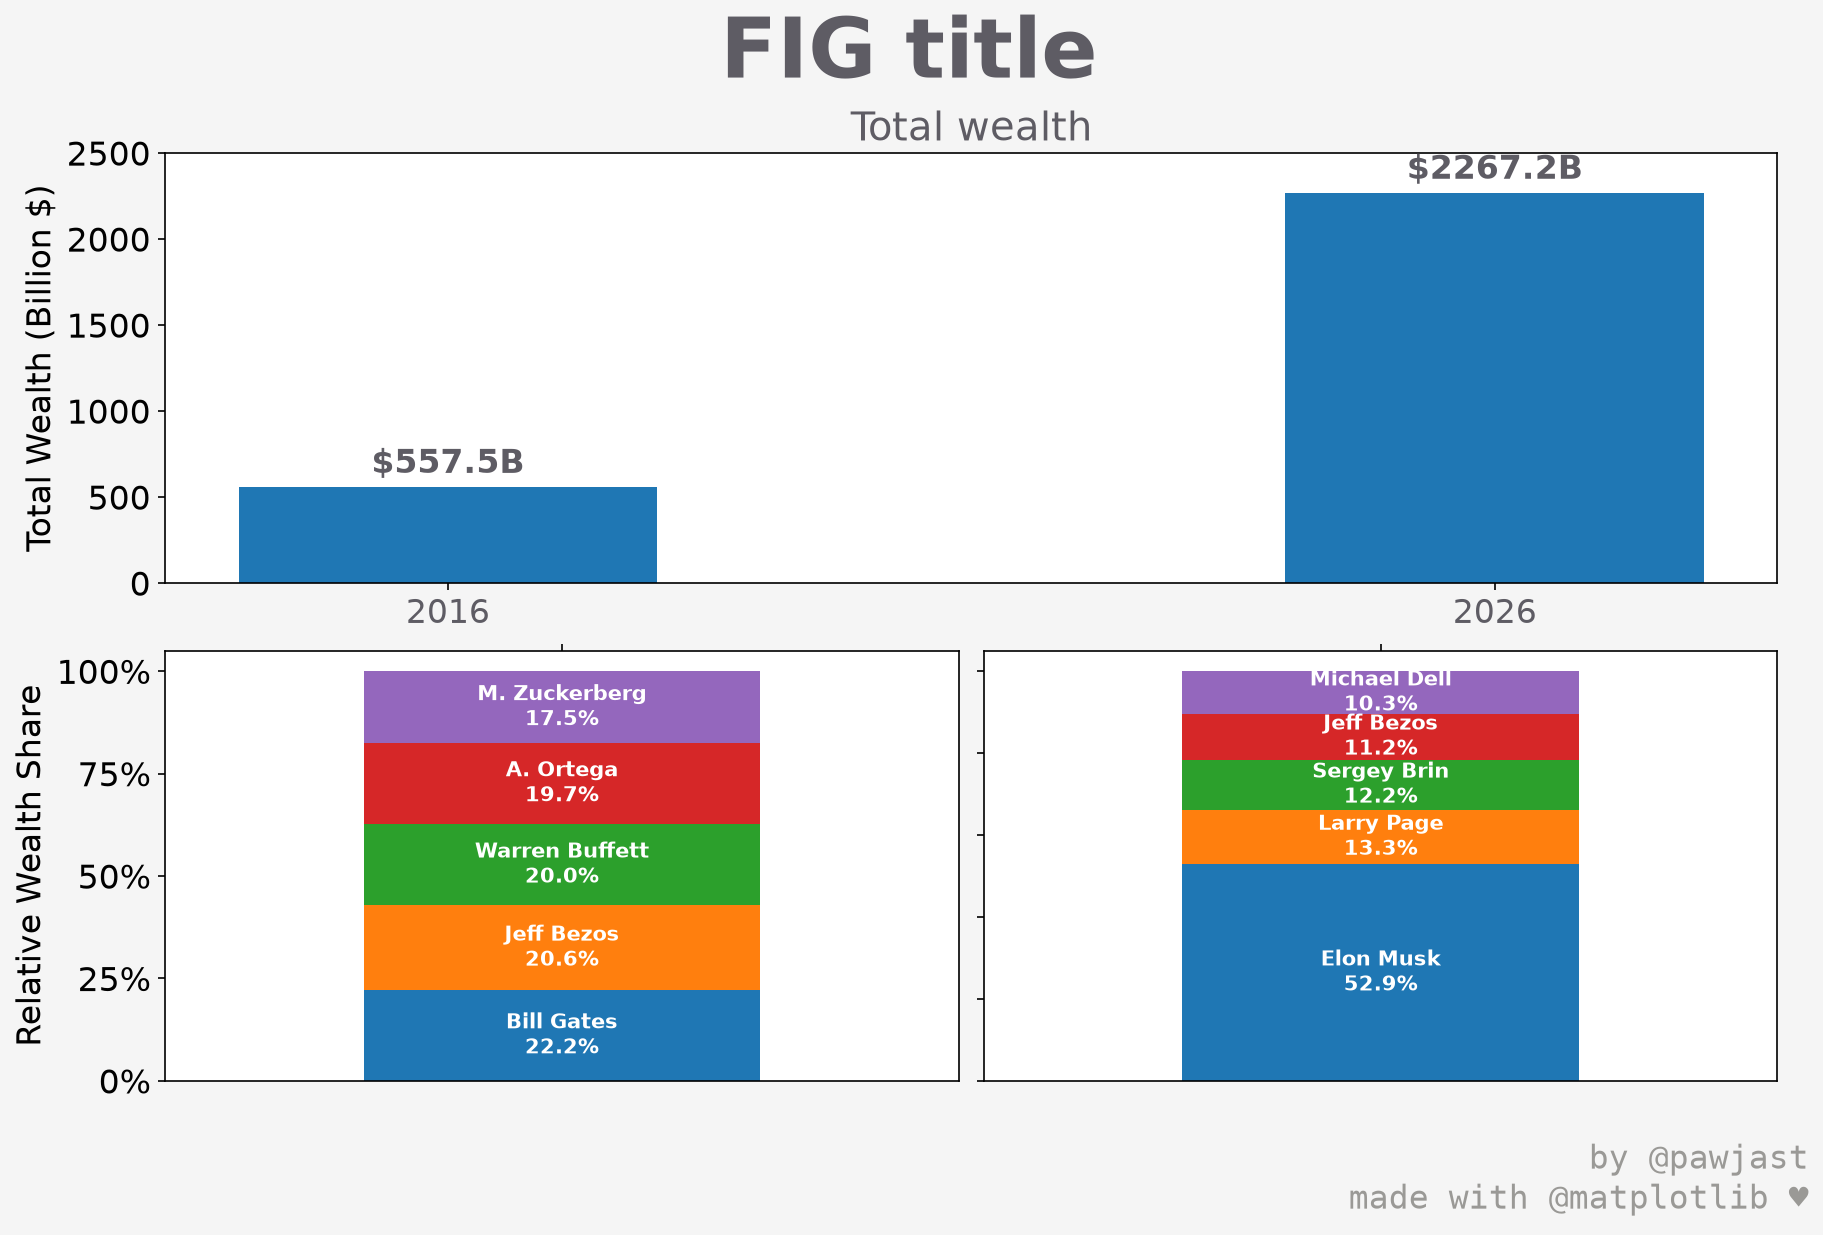

In [197]:
mosaic = """
    TT
    LR
"""

fig, axs = plt.subplot_mosaic(
    mosaic,
    per_subplot_kw={
        "R": {"sharey": axs["L"]}  # Connects R's Y-axis directly to L
    },
)

fig.suptitle(
    "FIG title",
    fontsize=40,
    weight="bold"
)

# --- Top Plot: Totals ---
axs["T"].set_title("Total wealth")
top_bars = axs["T"].bar(
    x=data_totals.index,
    height=data_totals["Total Wealth"],
    width=0.4
)

# Add value labels above the top bars
axs["T"].bar_label(top_bars, padding=3, fmt="$%.1fB", weight="bold")

axs["T"].set_ylabel("Total Wealth (Billion $)")
axs["T"].set_ylim(0, 2500)

# --- Bottom Plots ---
plot_configs = [
    ("L", data_2016),
    ("R", data_2026)
]

for ax_key, df in plot_configs:
    ax = axs[ax_key]
    
    # 1. Plot the stacked bar
    df[["relative"]].T.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        legend=False,
    )
    
    # 2. Format axes placement
    ax.xaxis.tick_top()
    ax.set_xticklabels([])
    ax.set_xlabel("") # Clear out the auto-generated "relative" text
    
    # 3. Add dynamic text labels
    for i, container in enumerate(ax.containers):
        name = df.index[i]  # Fetch billionaire name
        for bar in container:
            height = bar.get_height()
            if height > 0:  # Only label visible blocks
                x_pos = bar.get_x() + bar.get_width() / 2
                y_pos = bar.get_y() + height / 2
                label_text = f"{name}\n{height*100:.1f}%"
                
                ax.text(
                    x_pos, y_pos, label_text,
                    ha="center", va="center", color="white", weight="bold", fontsize=10
                )

axs["L"].set_ylabel("Relative Wealth Share")
axs["L"].set_yticks(
    ticks=np.arange(0, 1.25, 0.25),
    labels=[f"{tick * 100:.0f}%" for tick in np.arange(0, 1.25, 0.25)]
)

# Footer
axs["R"].text(
    1,
    -0.01,
    "by @pawjast\nmade with @matplotlib \u2665",
    transform=fig.transFigure,
    horizontalalignment="right",
    verticalalignment="bottom",
    color="#9a9996",
    fontsize=16,
    family="monospace",
    weight="medium",
);